# Modelagem e Simulação Multifísica - Aula 03

## 2 - Exemplo de um retificador de meia onda

### 2.1 - O problema de valor inicial

Considere o circuito retificador da figura a seguir. O circuito é alimentado por uma fonte de tensão real com tensão conhecida $V_{src}(t)$ e resistência $R_{src}=50 \Omega$. O circuito é usado para alimentar uma carga $R_{load}$ em paralelo com o resistor $C1$.
<p>
    <img width="500" height="100" src="./Figs/Halfwave_geo.png">
</p>
<p>
    <em> <a href="https://www.circuitlab.com/editor/#?id=4da864"> Circuito retificador de meia onda </a>. Fonte: https://www.circuitlab.com//</em>
</p>

A resposta transitória deste circuito pode ser visualizada na opção  <em> run -> time domain simulation </em> no link da figura. Repare que a solução da figura utiliza o modelo completo do diodo 1N4007. Entretanto, nesse trabalho usaremos o modelo simplificado do diodo real descrito por:

\begin{equation}
i_D(t) = I_S(\epsilon^{\frac{V_D(t)}{nV_T}} - 1)
\end{equation}

onde: 

* $I_S$ é a corrente de saturação do diodo, 
* $n$ fator de idealidade $(1\le n \le 2)$
* $V_T = \frac{kT}{q}$ é a tensão térmica do diodo,
    - q é a carga do elétron,
    - T é a temperatura em Kelvins, 
    - k a constante de Boltzmann.

Os valores utilizados na simulação são apresentados a seguir

In [1]:
# diode parameters
Is = 3.872e-9 #(A)
n = 1.776
q = 1.6e-19 #(C)
T = 300 #(K) - 26.85 (C)
k = 1.380649e-23 #(J/K)

nVT = n*k*T/q
# print(nVT/n) # VT approx 25mV.

Como o circuito possui apenas duas malhas, precisamos encontrar duas equações linearmente independentes para descrever o funcionamento do circuito. Nesse caso, usaremos a lei de kirchhoff das tensões (LKT) para a malha contendo a fonte:

\begin{equation}
V_{src} = R_{src}i_D + V_D + V_C
\end{equation}

e a lei de kirchhoff das correntes (LKC) no nó após o diodo:

\begin{equation}
i_D = i_C + R_{load}V_C
\end{equation}

Com isso temos três equações (sendo uma não-linear) para quatro incógnitas. O problema pode ser equacionado adicionando-se a ODE que relaciona a corrente e a tensão no capacitor:

\begin{equation}
i_C = C1\frac{dV_C}{dt}
\end{equation}

Assumindo que a fonte é ligada no instante de tempo $t_0$, o problema de valor inicial estará completo se é conhecida a energia armazenada no capacitor no momento imediatamente antes de $t_0$, ($t_{0^-}$). Nesse exemplo iremos considerar o capacitor descarregado, $V_C(t_0)=0$.

### 2.2 - Representação por espaço de estados

Para resolver o problema usando a representação por espaço de estados, devemos reescrever o problema na forma $\dot x=f(t,x)$. Assim a equação da corrente no capacitor pode ser reescrita como:

\begin{eqnarray}
\dot V_C &=& \frac{1}{C1}i_C
\end{eqnarray}

onde o lado esquerdo da equação deve ser reescrito em termos da tensão de entrada e a própria tensão no capacitor. Reescrevendo a LKC:

\begin{eqnarray}
i_C &=& i_D-\frac{V_C}{R_{load}}
\end{eqnarray}

sendo que $i_D$ pode ser eliminado usando a LKT. 

\begin{eqnarray}
i_D &=& \frac{V_{src} - V_D - V_C}{R_{src}}
\end{eqnarray}

Por fim a equação de estado pode ser escrita como:

\begin{eqnarray}
\dot V_C &=& \frac{1}{C1}\left[ \frac{V_{src} - V_D - V_C}{R_{src}} - \frac{V_C}{R_{load}} \right]
\end{eqnarray}

onde o termo $V_D$ é obtido por meio da solução da equação não linear oriunda do rearranjo da LKT e a equação do diodo.

\begin{eqnarray}
R_{src}I_S\left( e^{\frac{V_D}{nV_T}} - 1 \right) + V_D +V_C - V_{src} &=& 0
\end{eqnarray}

É importante lembrar que a representação por espaço de estado apresentada aqui não é única. Tente obter outras representações, usando por exemplo a análise nodal do circuito.

### 3.3 - Resolvendo por meio da função solve_ivp

A seguir o método é ilustrado usando a"RK45 (default): Explicit Runge-Kutta method of order 5(4)".

Definindo os parâmetros do problema e a função de entrada $V_{src}(t)$:

In [2]:
import matplotlib.pyplot as plt
from scipy import signal
import numpy as np

# Circuit parameters (International System of Units)
Rsrc = 50
Rload = 1e3
C1 = 10e-6

# Source parameters
freq = 60 # square wave frequency 
Amp = 12 # Voltage amplitude

# time domain simulation parameters
t_0 = 0
t_end = (1/60)*5

# PVI initial condition
x_0 = [0] # initial condition [Vc_0]

# V_src(t) function
def v_src(t): # function f(x(t),t) 
    return Amp*np.sin(2 * np.pi*freq*t)

Definindo a função de entrada $\dot x = f(t,x)$ usada na função solve_ivp

In [3]:
from scipy.optimize import fsolve

def vd(x,vc,vsrc):
    return Rsrc*Is*(np.exp(x/nVT) -1 ) + x + vc - vsrc

def f(t,x): # function f(x(t),t) 
    VD = fsolve(vd, 0, args=(x,v_src(t)),maxfev=100)
    return 1/C1*((v_src(t) - VD - x)/Rsrc - x/Rload)

Resolvendo o PVI e plotando as variáveis de saída.

/tmp/ipykernel_604/3851233900.py:7: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  VD = fsolve(vd, 0, args=(x,v_src(t)),maxfev=100)


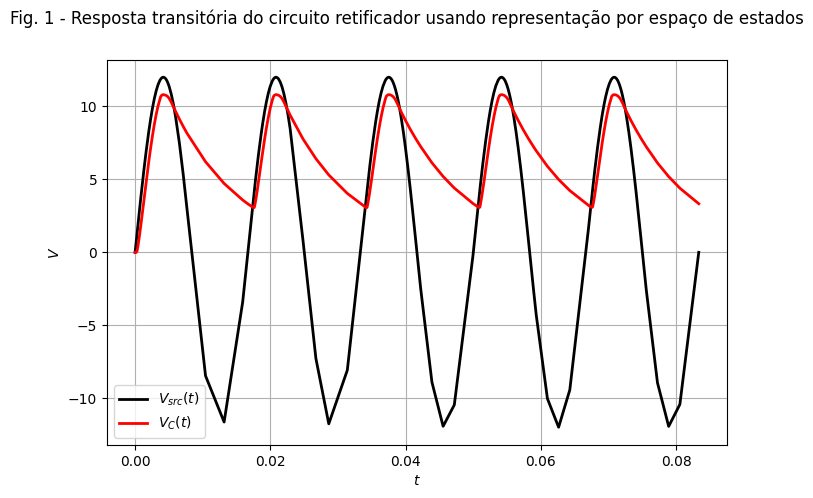

In [4]:
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

sol = solve_ivp(f, [t_0, t_end],x_0,method='LSODA')

# plot horizontal line
fig = plt.figure(figsize=(8,5))
plt.plot(sol.t, v_src(sol.t), 'k', linewidth=2);
plt.plot(sol.t, sol.y[0,:], 'r', linewidth=2); 
plt.grid(True);
plt.xlabel('$t$');
plt.ylabel('$V$');
plt.legend(['$V_{src}(t)$','$V_C(t)$'], loc='lower left');
fig.suptitle('Fig. 1 - Resposta transitória do circuito retificador usando representação por espaço de estados');